# Predicting which first-time buyers will come back

**Goal:** at the moment a first order is delivered, score how likely the customer is to buy again within 180 days,
so a retention budget (vouchers, emails) goes to the customers most likely to respond.

**Setup**
- One row per first-time buyer whose first order leaves a full 180-day observation window (58K customers).
- Label: bought again within 180 days. **Only ~3% do**, so this is a heavily imbalanced problem.
- **Time-based split:** train on first orders before Oct 2017, test on Oct 2017 - Mar 2018. A random split would leak future behaviour.
- Judged on **ranking** (PR-AUC, lift by decile), not accuracy. Predicting "nobody returns" is 97% accurate and useless.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from src.plotting import BLUE, INK, INK_2, ORANGE, clean, save, title

df = duckdb.connect("../data/processed/olist.duckdb", read_only=True).sql("select * from first_orders").df()

CATEGORICAL = ["customer_state", "category", "payment_type"]
NUMERIC = ["order_value", "items_value", "freight_value", "freight_share", "item_count", "seller_count",
           "photo_count", "weight_g", "installments", "delivery_days", "days_vs_estimate", "review_score",
           "purchase_dow", "purchase_hour", "purchase_month", "used_voucher"]

df["used_voucher"] = df.used_voucher.astype(int)
for c in CATEGORICAL:
    df[c] = df[c].fillna("unknown").astype("category")
y = df.bought_again.astype(int)
X = df[CATEGORICAL + NUMERIC]

train = df.purchased_at < "2017-10-01"
test = ~train
print(f"train: {train.sum():,} customers, {y[train].mean():.2%} repeat")
print(f"test:  {test.sum():,} customers, {y[test].mean():.2%} repeat")

train: 26,298 customers, 3.44% repeat
test:  31,795 customers, 2.93% repeat


## Models
1. **Baseline:** logistic regression (one-hot categoricals, scaled numerics)
2. **Gradient boosting:** `HistGradientBoostingClassifier` with native categorical support, regularised to avoid overfitting the rare positive class

In [2]:
logit = make_pipeline(
    ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), CATEGORICAL),
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUMERIC),
    ]),
    LogisticRegression(max_iter=2000, class_weight="balanced"),
)
gbm = HistGradientBoostingClassifier(categorical_features="from_dtype", max_iter=300, learning_rate=0.05,
                                     max_leaf_nodes=15, l2_regularization=1.0, random_state=0)

results = {}
for name, model in [("Logistic regression", logit), ("Gradient boosting", gbm)]:
    model.fit(X[train], y[train])
    p = model.predict_proba(X[test])[:, 1]
    results[name] = p

base = y[test].mean()
summary = pd.DataFrame({
    name: {"ROC-AUC": roc_auc_score(y[test], p),
           "PR-AUC": average_precision_score(y[test], p),
           "PR-AUC / base rate": average_precision_score(y[test], p) / base}
    for name, p in results.items()
}).T.round(3)
summary

,ROC-AUC,PR-AUC,PR-AUC / base rate
Logistic regression,0.596,0.042,1.441
Gradient boosting,0.599,0.042,1.440


## Lift by decile: the business view
Rank test customers by predicted score and split them into 10 equal groups. How much more likely is each group to come back than average?

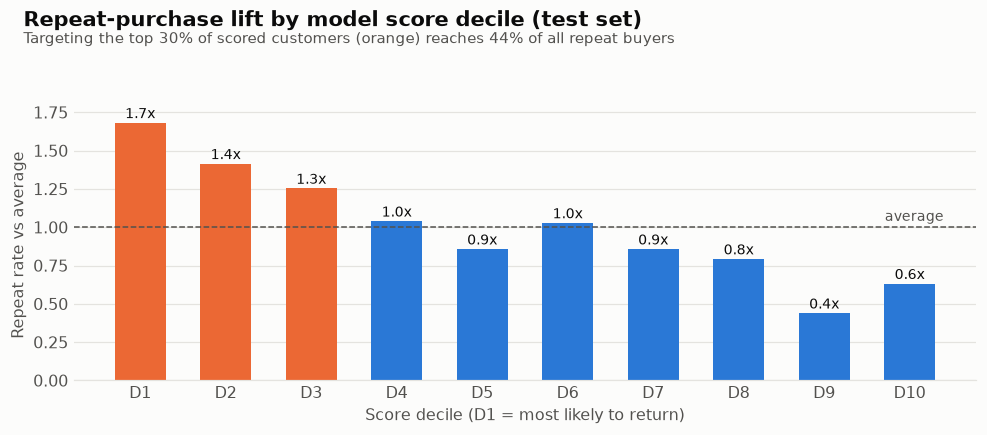

,mean,sum,lift,cumulative_capture
decile,,,,
1,0.049,157,1.682,0.168
2,0.042,132,1.415,0.310
3,0.037,117,1.254,0.435
4,0.031,97,1.040,0.539
5,0.025,80,0.858,0.625
6,0.030,96,1.029,0.728
7,0.025,80,0.858,0.814
8,0.023,74,0.793,0.893
9,0.013,41,0.440,0.937


In [3]:
p = results["Gradient boosting"]
d = pd.DataFrame({"y": y[test].values, "p": p})
d["decile"] = 10 - pd.qcut(d.p.rank(method="first"), 10, labels=False)  # 1 = highest scores
lift = d.groupby("decile").y.agg(["mean", "sum"])
lift["lift"] = lift["mean"] / d.y.mean()
lift["cumulative_capture"] = lift["sum"].cumsum() / d.y.sum()

fig, ax = plt.subplots(figsize=(9, 4))
colors = [ORANGE if i <= 3 else BLUE for i in lift.index]
ax.bar(lift.index, lift["lift"], color=colors, width=0.6)
ax.axhline(1, color=INK_2, linewidth=1, linestyle="--")
ax.text(10.4, 1.02, "average", color=INK_2, fontsize=9, ha="right", va="bottom")
for i, v in zip(lift.index, lift["lift"]):
    ax.text(i, v + 0.03, f"{v:.1f}x", ha="center", fontsize=9, color=INK)
ax.set_xticks(lift.index, [f"D{i}" for i in lift.index])
ax.set_xlabel("Score decile (D1 = most likely to return)")
ax.set_ylabel("Repeat rate vs average")
clean(ax)
top3 = lift.loc[3, "cumulative_capture"]
title(fig, "Repeat-purchase lift by model score decile (test set)",
      f"Targeting the top 30% of scored customers (orange) reaches {top3:.0%} of all repeat buyers")
save(fig, "lift_by_decile.png")
plt.show()
lift.round(3)

## What drives the score?
Permutation importance on the test set: how much PR-AUC drops when a feature is shuffled.

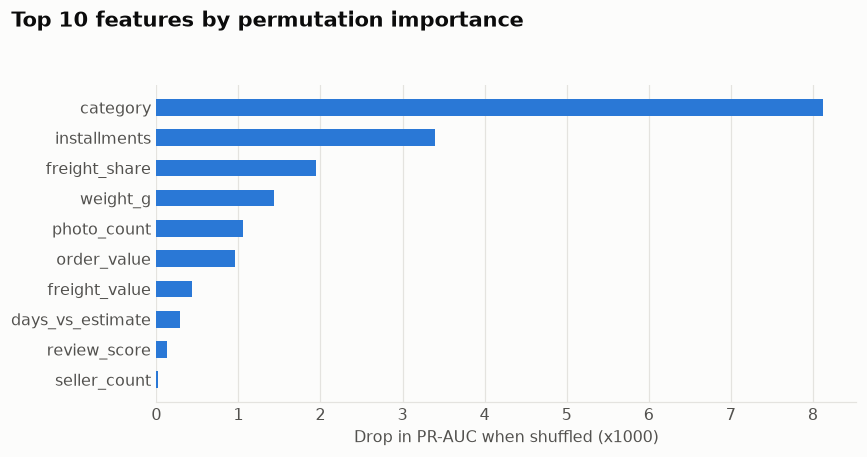

In [4]:
imp = permutation_importance(gbm, X[test], y[test], scoring="average_precision", n_repeats=5, random_state=0)
importance = (pd.Series(imp.importances_mean, index=X.columns).sort_values(ascending=True).tail(10))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(importance.index, importance.values * 1000, color=BLUE, height=0.55)
ax.set_xlabel("Drop in PR-AUC when shuffled (x1000)")
clean(ax, grid_axis="x")
title(fig, "Top 10 features by permutation importance")
save(fig, "feature_importance.png")
plt.show()

## Conclusions

- **The signal is real but modest** (ROC-AUC about 0.60, PR-AUC 1.4x the base rate). First-order data alone can't say *who* will come back, and that is an honest result, not a modelling failure: in this marketplace repeat purchase is rare and mostly driven by things the data doesn't capture (future needs, competitors, marketing).
- **The simple model is as good as the complex one.** Logistic regression (0.596) matches gradient boosting (0.599), so in production I'd ship the logistic model: it's cheaper to run and its coefficients are easy to explain to a marketing team.
- **It's still useful for budget allocation.** Customers in the top score decile return at 1.7x the average rate, and the top 30% contain 44% of all repeat buyers. A voucher campaign aimed at the top 3 deciles reaches 44% of likely returners for 30% of the cost.
- **Product category matters most**, followed by instalments and freight share: some categories (home goods, consumables) naturally invite a second purchase, and customers who pay in instalments or face high freight relative to basket size behave differently.
- **Next steps:** add behavioural signals (site visits, email engagement, wishlists), post-purchase marketing touchpoints and seller quality. Then run the campaign as an **A/B test** so the model is judged on incremental revenue, not only ranking metrics.